# Binomial Model in Practice

### Cox-Ross-Rubinstein (1979) Binomial Tree

In [1]:
import numpy as np
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    sign = 1 if option_type == 'call' else -1
    return sign * (S * norm.cdf(sign * d1) - K * np.exp(-r * T) * norm.cdf(sign * d2))

def binomial(S, K, T, r, sigma, n, option_type='call', exercise_type='european', model='CRR'):
    dt = T / n
    df = np.exp(-r * dt)
    sign = 1 if option_type == 'call' else -1
    if model == 'CRR':
        u = np.exp(sigma * np.sqrt(dt))
        d = 1 / u
        q = (np.exp(r * dt) - d) / (u - d)
    
    # 1. Initialize terminal payoffs
    prices = S * (u**np.arange(n, -1, -1)) * (d**np.arange(n + 1))
    values = np.maximum(sign * (prices - K), 0)
    
    # 2. Backward induction
    for i in range(n - 1, -1, -1):
        values = df * (q * values[:-1] + (1 - q) * values[1:])
        
        if exercise_type == 'american':
            prices = prices[:-1] / u 
            exercise = np.maximum(sign * (prices - K), 0)
            values = np.maximum(exercise, values)
        
    return values[0]

### Richardson Extrapolation

In [2]:
def richardson_extrapolation(S, K, T, r, sigma, n, option_type='call', exercise_type='european', model='CRR'):
    price_n  = binomial(S, K, T, r, sigma, n, option_type, exercise_type, model)
    price_2n = binomial(S, K, T, r, sigma, 2 * n, option_type, exercise_type, model)
    price_extrapol = 2 * price_2n - price_n
    return price_extrapol, price_n, price_2n

### Black-Scholes Smoothing

In [3]:
def binomial_bss(S, K, T, r, sigma, n, option_type='call', exercise_type='european', model='CRR'):
    dt = T / n
    df = np.exp(-r * dt)
    sign = 1 if option_type == 'call' else -1
    if model == 'CRR':
        u = np.exp(sigma * np.sqrt(dt))
        d = 1 / u
        q = (np.exp(r * dt) - d) / (u - d)

    # 1. Initialize terminal payoffs at N-1
    n_prev = n - 1
    prices = S * (u**np.arange(n_prev, -1, -1)) * (d**np.arange(n_prev + 1))
    values = np.array([black_scholes(s, K, dt, r, sigma, option_type) for s in prices])
    
    # Check Early Exercise at N-1
    if exercise_type == 'american':
        values = np.maximum(values, np.maximum(sign * (prices - K), 0))
    
    # 2. Backward induction
    for i in range(n_prev - 1, -1, -1):
        values = df * (q * values[:-1] + (1 - q) * values[1:])
        
        if exercise_type == 'american':
            prices = prices[:-1] / u 
            exercise = np.maximum(sign * (prices - K), 0)
            values = np.maximum(exercise, values)
        
    return values[0]

### Leisen-Reimer (1996) Binomial Tree 

In [4]:
def binomial(S, K, T, r, sigma, n, option_type='call', exercise_type='european', model='CRR'):
    if model == 'LR' and n % 2 == 0: n += 1
    
    dt = T / n
    df = np.exp(-r * dt)
    sign = 1 if option_type == 'call' else -1
    if model == 'CRR':
        u = np.exp(sigma * np.sqrt(dt))
        d = 1 / u
        q = (np.exp(r * dt) - d) / (u - d)
    elif model == 'LR':
        def peizer_pratt(z, n):
            inner = -((z / (n + 1/3 + 0.1/(n+1)))**2) * (n + 1/6)
            return 0.5 + np.sign(z) * 0.5 * np.sqrt(1 - np.exp(inner))
        
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        q_prime = peizer_pratt(d1, n)
        q       = peizer_pratt(d2, n)
        
        u = np.exp(r * dt) * q_prime / q
        d = (np.exp(r * dt) - q * u) / (1 - q)
    
    # 1. Initialize terminal payoffs
    prices = S * (u**np.arange(n, -1, -1)) * (d**np.arange(n + 1))
    values = np.maximum(sign * (prices - K), 0)
    
    # 2. Backward induction
    for i in range(n - 1, -1, -1):
        values = df * (q * values[:-1] + (1 - q) * values[1:])
        
        if exercise_type == 'american':
            prices = prices[:-1] / u 
            exercise = np.maximum(sign * (prices - K), 0)
            values = np.maximum(exercise, values)
        
    return values[0]

### Sanity Check

In [5]:
S, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.20
n = 100

print(f"black scholes: {black_scholes(S, K, T, r, sigma, 'put')}")
print(f"binomial crr: {binomial(S, K, T, r, sigma, n, 'put', 'european')}")
print(f"richardson extrapolation: {richardson_extrapolation(S, K, T, r, sigma, n, 'put', 'european')}")
print(f"binomial bss: {binomial_bss(S, K, T, r, sigma, n, 'put', 'european')}")
print(f"binomial lr: {binomial(S, K, T, r, sigma, n, 'put', 'european', 'LR')}")

black scholes: 5.573526022256971
binomial crr: 5.553554112321353
richardson extrapolation: (np.float64(5.573513307539785), np.float64(5.553554112321353), np.float64(5.563533709930569))
binomial bss: 5.578621081990315
binomial lr: 5.57349178663854


In [6]:
S, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.20
n = 100

print(f"binomial crr: {binomial(S, K, T, r, sigma, n, 'put', 'american')}")
print(f"richardson extrapolation: {richardson_extrapolation(S, K, T, r, sigma, n, 'put', 'american')}")
print(f"binomial bss: {binomial_bss(S, K, T, r, sigma, n, 'put', 'american')}")
print(f"binomial lr: {binomial(S, K, T, r, sigma, n, 'put', 'american', 'LR')}")

binomial crr: 6.082354409142446
richardson extrapolation: (np.float64(6.090411090689728), np.float64(6.082354409142446), np.float64(6.086382749916087))
binomial bss: 6.09514686636031
binomial lr: 6.087222149481529


### Convergence Plot (example)

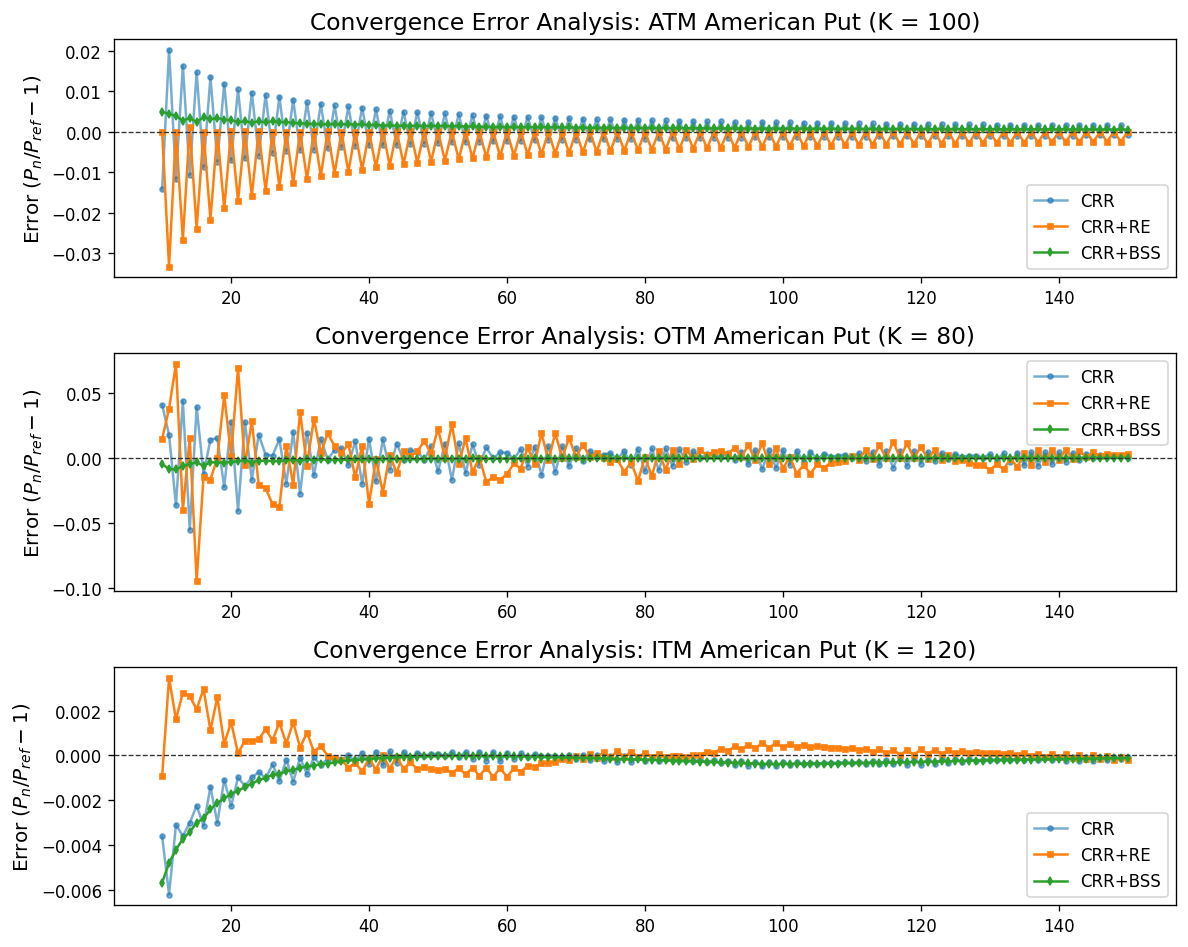

In [7]:
import matplotlib.pyplot as plt

S, K, T, r, sigma,  = 100, 100, 1.0, 0.05, 0.20
fig, axs = plt.subplots(3, 1, figsize=(10, 8), dpi=120)

# Plotting 1
n_range = range(10, 151, 1)
errors_standard  = []
errors_richardson = []
errors_bss = []
reference = binomial(S, 100, T, r, sigma, 5000, 'put', 'american')
for n in n_range:
    price_extrap, price_n, _ = richardson_extrapolation(S, 100, T, r, sigma, n, 'put', 'american')
    price_n_bss = binomial_bss(S, 100, T, r, sigma, n, 'put', 'american')
    price_bss = binomial_bss(S, K, T, r, sigma, n)
    errors_standard.append(price_n/reference-1)
    errors_richardson.append(price_extrap/reference-1)
    errors_bss.append(price_n_bss/reference-1)

axs[0].plot(list(n_range), errors_standard, 'o-', alpha=0.6, markersize=3, label='CRR')
axs[0].plot(list(n_range), errors_richardson, 's-', linewidth=1.5, markersize=3, label='CRR+RE')
axs[0].plot(list(n_range), errors_bss, 'd-', linewidth=1.5, markersize=3, label='CRR+BSS')
axs[0].axhline(0, color='#333333', linestyle='--', linewidth=0.8)
axs[0].set_title("Convergence Error Analysis: ATM American Put (K = 100)", fontsize=14)
axs[0].set_ylabel('Error ($P_n/P_{ref}-1$)', fontsize=12)
axs[0].legend()

# Plotting 2
n_range = range(10, 151, 1)
errors_standard  = []
errors_richardson = []
errors_bss = []
reference = binomial(S, 80, T, r, sigma, 5000, 'put', 'american')
for n in n_range:
    price_extrap, price_n, _ = richardson_extrapolation(S, 80, T, r, sigma, n, 'put', 'american')
    price_n_bss = binomial_bss(S, 80, T, r, sigma, n, 'put', 'american')
    price_bss = binomial_bss(S, K, T, r, sigma, n)
    errors_standard.append(price_n/reference-1)
    errors_richardson.append(price_extrap/reference-1)
    errors_bss.append(price_n_bss/reference-1)

axs[1].plot(list(n_range), errors_standard, 'o-', alpha=0.6, markersize=3, label='CRR')
axs[1].plot(list(n_range), errors_richardson, 's-', linewidth=1.5, markersize=3, label='CRR+RE')
axs[1].plot(list(n_range), errors_bss, 'd-', linewidth=1.5, markersize=3, label='CRR+BSS')
axs[1].axhline(0, color='#333333', linestyle='--', linewidth=0.8)
axs[1].set_title("Convergence Error Analysis: OTM American Put (K = 80)", fontsize=14)
axs[1].set_ylabel('Error ($P_n/P_{ref}-1$)', fontsize=12)
axs[1].legend()

# Plotting 3
n_range = range(10, 151, 1)
errors_standard  = []
errors_richardson = []
errors_bss = []
reference = binomial(S, 120, T, r, sigma, 5000, 'put', 'american')
for n in n_range:
    price_extrap, price_n, _ = richardson_extrapolation(S, 120, T, r, sigma, n, 'put', 'american')
    price_n_bss = binomial_bss(S, 120, T, r, sigma, n, 'put', 'american')
    price_bss = binomial_bss(S, K, T, r, sigma, n)
    errors_standard.append(price_n/reference-1)
    errors_richardson.append(price_extrap/reference-1)
    errors_bss.append(price_n_bss/reference-1)

axs[2].plot(list(n_range), errors_standard, 'o-', alpha=0.6, markersize=3, label='CRR')
axs[2].plot(list(n_range), errors_richardson, 's-', linewidth=1.5, markersize=3, label='CRR+RE')
axs[2].plot(list(n_range), errors_bss, 'd-', linewidth=1.5, markersize=3, label='CRR+BSS')
axs[2].axhline(0, color='#333333', linestyle='--', linewidth=0.8)
axs[2].set_title("Convergence Error Analysis: ITM American Put (K = 120)", fontsize=14)
axs[2].set_ylabel('Error ($P_n/P_{ref}-1$)', fontsize=12)
axs[2].legend()

plt.tight_layout()
plt.show()